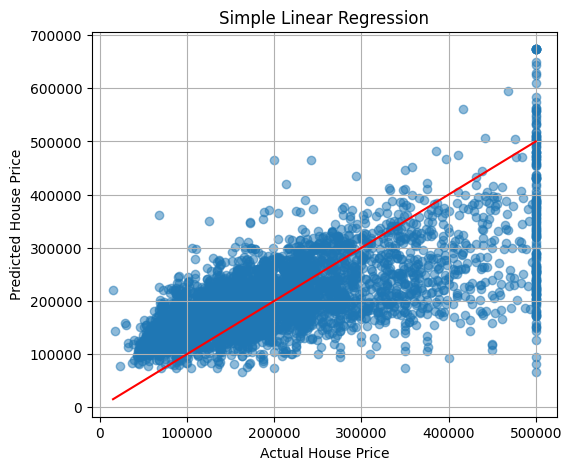

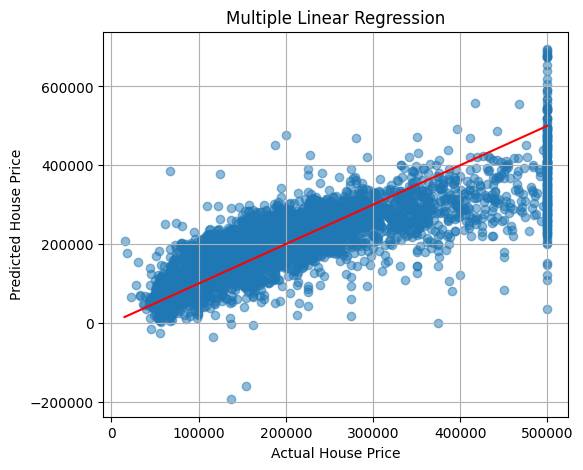

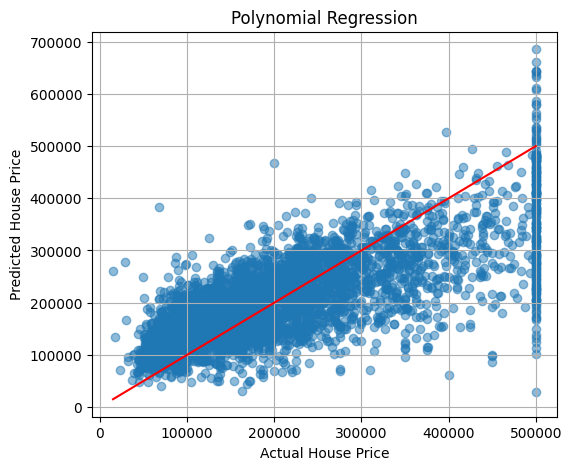

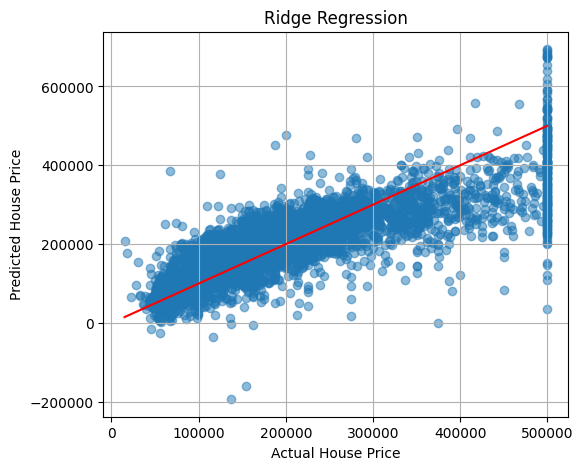

In [7]:
# 23mid0319

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

url = "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv"
df = pd.read_csv(url)

X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

num_cols = X_train.select_dtypes(include=np.number).columns
cat_cols = X_train.select_dtypes(exclude=np.number).columns

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
])

# Simple Linear Regression
simple_model = LinearRegression()
simple_model.fit(X_train[["median_income"]], y_train)
simple_pred = simple_model.predict(X_test[["median_income"]])

# Multiple Linear Regression
multiple_model = Pipeline([
    ("preprocess", preprocess),
    ("model", LinearRegression())
])

multiple_model.fit(X_train, y_train)
multiple_pred = multiple_model.predict(X_test)

# Polynomial Regression
poly_features = ["median_income", "housing_median_age", "total_rooms"]

poly_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

poly_model.fit(X_train[poly_features], y_train)
poly_pred = poly_model.predict(X_test[poly_features])

# Ridge Regression
ridge_model = Pipeline([
    ("preprocess", preprocess),
    ("model", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_test)

# Plot Graphs
models = [
    ("Simple Linear Regression", simple_pred),
    ("Multiple Linear Regression", multiple_pred),
    ("Polynomial Regression", poly_pred),
    ("Ridge Regression", ridge_pred)
]

for name, pred in models:
    plt.figure(figsize=(6,5))
    plt.scatter(y_test, pred, alpha=0.5)
    plt.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        color="red"
    )
    plt.title(name)
    plt.xlabel("Actual House Price")
    plt.ylabel("Predicted House Price")
    plt.grid(True)
    plt.show()